In [101]:
%matplotlib inline

import sys
import numpy as np
from scipy import sparse
import pandas as pd
from anndata import AnnData


import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc


# Set these before creating your plot
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


# Load data

In [90]:
#Read the processed matrix
adata = sc.read_h5ad('adata_full.h5ad')
adata_TNK_relabeled = sc.read_h5ad('adata_TNK_processed.h5ad')

In [91]:
# Transfer the labels:
# Create a new column as a copy of cell_type_cg
adata.obs['cell_type_sub'] = adata.obs['cell_type_cg'].astype(str)

# For shared cells, update values from adata_TNK_relabeled
TNK_cells = adata_TNK_relabeled.obs_names
adata.obs.loc[TNK_cells, 'cell_type_sub'] = adata_TNK_relabeled.obs['cell_type_sub'].astype(str)

# Convert back to categorical
adata.obs['cell_type_sub'] = adata.obs['cell_type_sub'].astype('category')


In [92]:
# Update major labels to include B subsets
adata.obs['cell_type_major'] = adata.obs['cell_type_major'].astype(str)
B_cells = adata[adata.obs['cell_type_major']=='B'].obs_names
adata.obs.loc[B_cells, 'cell_type_major'] = adata.obs.loc[B_cells, 'cell_type_cg'].astype(str)
adata.obs['cell_type_major'] = adata.obs['cell_type_major'].astype('category')



In [93]:
# Remove genes with zero counts:
# Filter the AnnData object
adata = adata[:, adata.X.sum(axis=0).A1>0].copy()
print(f"Number of genes after filtering: {adata.n_vars}")



Number of genes after filtering: 53825


## Process and embed

In [94]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Identify highly variable genes
# Inheriting highly-variable genes from pre-processing
#sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3_paper')

# Normalize total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Tweak highly-variable:
#adata.var['highly_variable'] = adata.var['highly_variable'] & (np.array(adata.X.max(axis=0).todense())[0]>=15)

adata_unscaled = adata.copy()
# Log transform
#sc.pp.log1p(adata, base=10)

# Scale data - not scaling now
sc.pp.scale(adata, max_value=10)



In [95]:
print("Running PCA...")
# Run PCA
sc.tl.pca(adata, n_comps=50,use_highly_variable=True)

print("Computing neighborhood graph...")
# Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)

Running PCA...


/Users/allon/miniconda3/envs/py39_env/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


Computing neighborhood graph...


/Users/allon/miniconda3/envs/py39_env/lib/python3.9/multiprocessing/resource_tracker.py:96: UserWarning: resource_tracker: process died unexpectedly, relaunching.  Some resources might leak.
  warnings.warn('resource_tracker: process died unexpectedly, '
Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized

Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized



In [96]:
print("Running UMAP...")
# Run UMAP
sc.tl.umap(adata,min_dist=1.0,spread=3,random_state=0, maxiter=1000) #, maxiter=1000

Running UMAP...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX

In [97]:
print("Running Leiden clustering...")
# Run Leiden clustering
sc.tl.leiden(adata,
             resolution=1.5,
             key_added='leiden')

# Need to break CD4 Teff into 2 to bring out Foxp3+
# Need to break CD8 T_cyt into 3


# sc.tl.leiden(adata,
#              resolution=0.4,
#              restrict_to=('cell_type', 
#                           ['CD4 T$_{Naive/Mem}$']),
#              key_added='leiden_T_NK')


# # Combine all categories
# leiden_cats = adata.obs['leiden'].cat.categories
# leiden_tnk_cats = adata.obs['leiden_T_NK'].cat.categories
# all_cats = sorted(set(leiden_cats) | set(leiden_tnk_cats))

# # Update categories for both columns
# adata.obs['leiden'] = adata.obs['leiden'].cat.set_categories(all_cats)
# adata.obs['leiden_T_NK'] = adata.obs['leiden_T_NK'].cat.set_categories(all_cats)

# # Now do the assignment
# mask = adata.obs['cell_type'] == 'CD4 T$_{Naive/Mem}$'
# adata.obs.loc[mask, 'leiden'] = adata.obs.loc[mask, 'leiden_T_NK']

Running Leiden clustering...


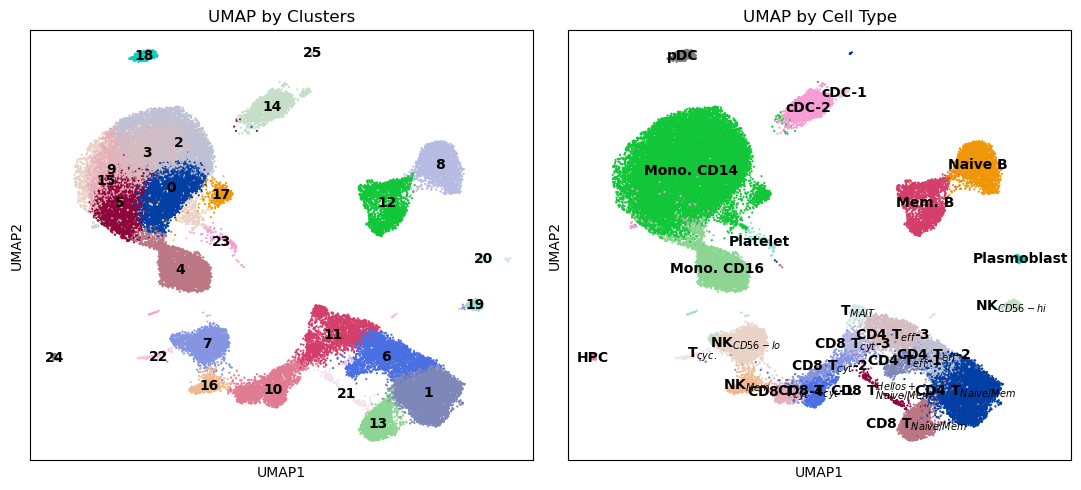

In [98]:

# Create a figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Plot UMAP with clusters
sc.pl.umap(adata, color='leiden', ax=ax1, size=10, show=False, title='UMAP by Clusters', legend_loc='on data')

# Plot UMAP with cell types
sc.pl.umap(adata, color='cell_type_sub', size=10, ax=ax2, show=False, title='UMAP by Cell Type', legend_loc='on data')

plt.tight_layout()
plt.show()

plt.close()


In [99]:
# Run rank_genes_groups to investigate un-annotated cluster 25
adata_unscaled.obs = adata.obs.copy()
sc.tl.rank_genes_groups(adata_unscaled, 
                       groupby='leiden',  # or whatever column has your clusters
                       method='wilcoxon'  # or 't-test', 'logreg', etc.
                       )

# Get results for cluster 25
sc.get.rank_genes_groups_df(adata_unscaled, group='25')

/Users/allon/miniconda3/envs/py39_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/allon/miniconda3/envs/py39_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/allon/miniconda3/envs/py39_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:440: P

,names,scores,logfoldchanges,pvals,pvals_adj
0,NOL7,4.175816,1.485451,2.969196e-05,0.116676
1,SLC16A10,4.169569,2.685355,3.051767e-05,0.116676
2,BCAS4,4.144228,1.340792,3.409609e-05,0.116676
3,WDR25,4.142321,2.441887,3.438089e-05,0.116676
4,URB1,4.140314,2.190057,3.468313e-05,0.116676
...,...,...,...,...,...
53820,MT-RNR1,-4.938880,-8.234984,7.857235e-07,0.008458
53821,NMNAT2,-5.173222,-8.536960,2.300917e-07,0.003096
53822,MALAT1,-5.226563,-10.189290,1.726898e-07,0.003096
53823,FP236383.3,-5.267686,-11.555403,1.381542e-07,0.003096


In [46]:
df=sc.get.rank_genes_groups_df(adata_unscaled, group='17')
df[df['pvals_adj']<2e-1].sort_values('logfoldchanges', ascending=False)

,names,scores,logfoldchanges,pvals,pvals_adj
1,EIF3C,31.246294,12.438088,2.506836e-214,6.746523e-210
0,EIF3CL,31.254969,12.330109,1.911118e-214,6.746523e-210
4,VCAN,23.467678,11.872691,8.725052e-122,9.392518e-118
5,MT-RNR2,22.234058,11.680308,1.609062e-109,1.443462e-105
3,LYZ,23.635147,10.886410,1.677929e-123,2.257864e-119
...,...,...,...,...,...
49840,GZMA,-3.307896,-5.348629,9.399961e-04,1.216233e-02
48788,ZNF507,-2.740784,-5.394988,6.129276e-03,6.309114e-02
48783,P2RY10,-2.738747,-28.325701,6.167380e-03,6.343574e-02
48177,CD8A,-2.446838,-28.358780,1.441155e-02,1.324854e-01


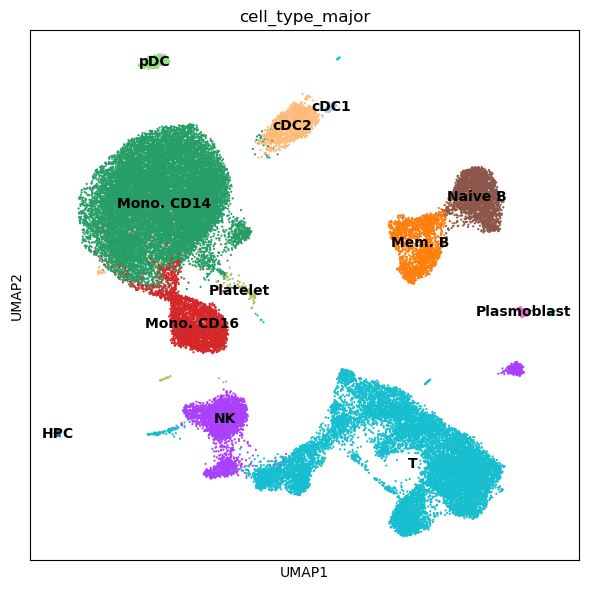

In [102]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.umap(adata, color='cell_type_major', ax=ax1, size=10, show=False, legend_loc='on data')
plt.tight_layout()
plt.savefig('fig_UMAP_major_types.pdf')
plt.show()

